In [14]:
import pandas as pd 
import numpy as np 

#ML
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from scipy import stats
import matplotlib.pyplot as plt
import os
import seaborn as sns
from tqdm import tqdm

## Tools

In [17]:
import pandas as pd
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import norm
import matplotlib.pyplot as plt

# Function to calculate confidence interval for accuracy
def compute_confidence_interval(accuracy, n, confidence=0.95):
    z = norm.ppf((1 + confidence) / 2)  # z-score for the given confidence level
    ci = z * np.sqrt((accuracy * (1 - accuracy)) / n)
    return accuracy - ci, accuracy + ci


## Automatic

In [29]:
simple_betas = [0.02,0.03,0.04,0.05]
complex_thetas = [2,3,4,5]
complex_probs = [0.02]
#0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
observable_ratio = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
observable_ratio = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
observable_ratio = [0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5]
observable_ratio = [0.01,0.05,0.1,0.15]
observable_ratio = [0.01,0.05,0.1,0.15,0.2,0.25,0.3]
observable_ratio = [0.01,0.05,0.1,0.15,0.2,0.25,0.3,0.35,0.4,0.45,0.5,0.55,0.6]
# observable_ratio = [0.1,0.2,0.3,0.4,0.5]

network_list = ['email_eu_modified']
# network_list = ['email_eu_modified','conf','school']

In [31]:
def add_tds_to_sims(sims,lambda_x=0.1):
    sims = sims.copy()
    tds_list = [] 
    for idx in tqdm(range(len(sims))):
        partial_ratio = sims["obs_ratio"].values[idx]
        seed_curr = sims["seed"].values[idx]
        order_columns = [col for col in sims.columns if str(col).isdigit() or (str(col).lstrip('-').isdigit())]
        partial_n_nodes = int(partial_ratio*len(order_columns))
        np.random.seed(seed_curr)
        order_columns_obs = np.random.choice(order_columns,partial_n_nodes,replace=False)
        
        order = sims[order_columns_obs].copy(deep=True)
        values_step_of_infection = order.iloc[idx].dropna().values
        tds = 0
        for step_curr in range(int(values_step_of_infection.min()),int(values_step_of_infection.max())):
            tds+= np.sum(values_step_of_infection == step_curr) * (lambda_x ** step_curr)

        tds_list.append(tds)
    return tds_list

In [49]:
for network_name in network_list:

    results_dir = '../result_85stop_10%init_nodes_limited-v4/unweighted/'
    complex_all = pd.DataFrame()
    
    for theta in tqdm(complex_thetas):
        for prob_complex in complex_probs:
            for obs_ratio in observable_ratio:
                
                #raw csv path
                csv_path = os.path.join(results_dir, f'unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}.csv')
                #path with EPH
                output_csv = csv_path.replace('.csv', f'limited-node_{obs_ratio}_EPH-v3.csv')
                
                df = pd.read_csv(output_csv)
                df["obs_ratio"] = obs_ratio
                
                complex_all = pd.concat([df,complex_all])  

    complex_all["EPH"] = complex_all["EPH"].fillna(0)
    complex_all["tds"] = add_tds_to_sims(complex_all)
    # Process simple contagion CSVs
    simple_all = pd.DataFrame()
    
    for obs_ratio in observable_ratio:
        for beta in simple_betas:
            #raw csv path
            csv_path = os.path.join(results_dir, f'unweighted_simple_{network_name}_beta_{beta}.csv')
            #path with EPH
            output_csv = csv_path.replace('.csv', f'limited-node_{obs_ratio}_EPH-v3.csv')
            
            df = pd.read_csv(output_csv)
            df["obs_ratio"] = obs_ratio
                
            simple_all = pd.concat([df,simple_all])  

    simple_all["EPH"] = simple_all["EPH"].fillna(0)
    simple_all["tds"] = add_tds_to_sims(simple_all)
    results = []
    for node_lim in tqdm(observable_ratio):
        simple_samples = simple_all.sample(frac=1,random_state=42)
        complex_samples = complex_all.sample(frac=1,random_state=42)
        
        if len(simple_samples) > len(complex_samples):
            simple_samples = simple_samples.sample(n=len(complex_samples),random_state=42)
        else:
            complex_samples = complex_samples.sample(n=len(simple_samples),random_state=42)
            
        # Extract features and labels
        complex_EPH = complex_samples[complex_samples["obs_ratio"] == node_lim][['corr','EPH']].values
        simple_EPH = simple_samples[simple_samples["obs_ratio"] == node_lim][['corr','EPH']].values

        # Extract features and labels
        complex_tds = complex_samples[complex_samples["obs_ratio"] == node_lim][['tds']].values
        simple_tds = simple_samples[simple_samples["obs_ratio"] == node_lim][['tds']].values
    
        
        X = np.concatenate([complex_EPH, simple_EPH]).reshape(-1, 2)  # Features
        X_tds = np.concatenate([complex_tds, simple_tds]).reshape(-1, 1)  # Features

        y = np.concatenate([np.ones(len(complex_EPH)), np.zeros(len(simple_EPH))])  # Labels (1=complex, 0=simple)
    
        # Shuffle data
        indices = np.arange(X.shape[0])
        np.random.seed(42) 
        np.random.shuffle(indices)
        X = X[indices]
        X_tds = X_tds[indices]
        y = y[indices]
    
        # Split into training and testing sets
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)
        X_train_tds, X_test_tds, y_train, y_test = train_test_split(X_tds, y, test_size=0.2, random_state=420)

        # Train Decision Tree Classifier
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train, y_train)
    
        # Evaluate the classifier
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        ci_lower, ci_upper = compute_confidence_interval(accuracy, len(y_test))

        # Train Decision Tree Classifier using TDS 
        clf = DecisionTreeClassifier(random_state=42)
        clf.fit(X_train_tds, y_train)
    
        # Evaluate the classifier
        y_pred = clf.predict(X_test_tds)
        accuracy_tds = accuracy_score(y_test, y_pred)
        ci_lower_tds, ci_upper_tds = compute_confidence_interval(accuracy_tds, len(y_test))
    
        
        # Store the results
        results.append({
            'node_lim': node_lim,
            'accuracy': accuracy,
            'ci_lower': ci_lower,
            'ci_upper': ci_upper,
            'accuracy_tds': accuracy_tds,
            'ci_lower_tds': ci_lower_tds,
            'ci_upper_tds': ci_upper_tds,
        })
    
    # Convert results to a DataFrame
    results_df = pd.DataFrame(results)
    results_df.to_csv(f'./res/{network_name}_results.csv')


100%|████████████████████████████████████| 10400/10400 [00:28<00:00, 365.48it/s]
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_33353/730462851.py:21: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  complex_all["tds"] = add_tds_to_sims(complex_all)
100%|████████████████████████████████████| 10400/10400 [00:30<00:00, 341.12it/s]
/var/folders/r3/27v441rd1vb2qdthw2f3whr00000gn/T/ipykernel_33353/730462851.py:38: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  simple_all["tds"] = add_tds_to_sims(simple_all)
100%|█████████████

In [50]:
# for network_name in network_list:

#     results_dir = '../result_85stop_10%init_nodes_limited-v4/unweighted/'
#     complex_all = pd.DataFrame()
    
#     for theta in tqdm(complex_thetas):
#         for prob_complex in complex_probs:
#             for obs_ratio in observable_ratio:
                
#                 #raw csv path
#                 csv_path = os.path.join(results_dir, f'unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}.csv')
#                 #path with EPH
#                 output_csv = csv_path.replace('.csv', f'limited-node_{obs_ratio}_EPH-v3.csv')
                
#                 df = pd.read_csv(output_csv)
#                 df["obs_ratio"] = obs_ratio
                
#                 complex_all = pd.concat([df,complex_all])  

#     complex_all["EPH"] = complex_all["EPH"].fillna(0)

#     # Process simple contagion CSVs
#     simple_all = pd.DataFrame()
    
#     for obs_ratio in observable_ratio:
#         for beta in simple_betas:
#             #raw csv path
#             csv_path = os.path.join(results_dir, f'unweighted_simple_{network_name}_beta_{beta}.csv')
#             #path with EPH
#             output_csv = csv_path.replace('.csv', f'limited-node_{obs_ratio}_EPH-v3.csv')
            
#             df = pd.read_csv(output_csv)
#             df["obs_ratio"] = obs_ratio
                
#             simple_all = pd.concat([df,simple_all])  

#     simple_all["EPH"] = simple_all["EPH"].fillna(0)

#     results = []
#     for node_lim in tqdm(observable_ratio):
#         simple_samples = simple_all.sample(frac=1,random_state=42)
#         complex_samples = complex_all.sample(frac=1,random_state=42)
        
#         if len(simple_samples) > len(complex_samples):
#             simple_samples = simple_samples.sample(n=len(complex_samples),random_state=42)
#         else:
#             complex_samples = complex_samples.sample(n=len(simple_samples),random_state=42)
            
#         # Extract features and labels
#         complex_EPH = complex_samples[complex_samples["obs_ratio"] == node_lim][['corr','EPH']].values
#         simple_EPH = simple_samples[simple_samples["obs_ratio"] == node_lim][['corr','EPH']].values
    
#         X = np.concatenate([complex_EPH, simple_EPH]).reshape(-1, 2)  # Features
#         y = np.concatenate([np.ones(len(complex_EPH)), np.zeros(len(simple_EPH))])  # Labels (1=complex, 0=simple)
    
#            # Shuffle data
#         indices = np.arange(X.shape[0])
#         np.random.seed(42) 
#         np.random.shuffle(indices)
#         X = X[indices]
#         y = y[indices]
    
#         # Split into training and testing sets
#         X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)
    
#         # Train Decision Tree Classifier
#         clf = DecisionTreeClassifier(random_state=42)
#         clf.fit(X_train, y_train)
    
#         # Evaluate the classifier
#         y_pred = clf.predict(X_test)
#         accuracy = accuracy_score(y_test, y_pred)
#         ci_lower, ci_upper = compute_confidence_interval(accuracy, len(y_test))
    
#         # Store the results
#         results.append({
#             'node_lim': node_lim,
#             'accuracy': accuracy,
#             'ci_lower': ci_lower,
#             'ci_upper': ci_upper
#         })
    
#     # Convert results to a DataFrame
#     results_df = pd.DataFrame(results)
#     results_df.to_csv(f'./res/{network_name}_results.csv')


In [51]:
network_name = "email_eu_modified"
results_df_email = pd.read_csv(f'./res/{network_name}_results.csv')
# network_name = "conf"
# results_df_conf = pd.read_csv(f'./res/{network_name}_results.csv')
# network_name = "school"
# results_df_school = pd.read_csv(f'./res/{network_name}_results.csv')

In [52]:
results_df_email

,Unnamed: 0,node_lim,accuracy,ci_lower,ci_upper,accuracy_tds,ci_lower_tds,ci_upper_tds
0,0,0.01,0.831250,0.790214,0.872286,0.496875,0.442093,0.551657
1,1,0.05,0.962500,0.941684,0.983316,0.690625,0.639980,0.741270
2,2,0.10,0.996875,0.990760,1.002990,0.628125,0.575172,0.681078
3,3,0.15,0.996875,0.990760,1.002990,0.637500,0.584830,0.690170
4,4,0.20,1.000000,1.000000,1.000000,0.609375,0.555919,0.662831
5,5,0.25,1.000000,1.000000,1.000000,0.609375,0.555919,0.662831
6,6,0.30,1.000000,1.000000,1.000000,0.600000,0.546324,0.653676
7,7,0.35,1.000000,1.000000,1.000000,0.640625,0.588054,0.693196
8,8,0.40,1.000000,1.000000,1.000000,0.596875,0.543130,0.650620
9,9,0.45,1.000000,1.000000,1.000000,0.634375,0.581608,0.687142


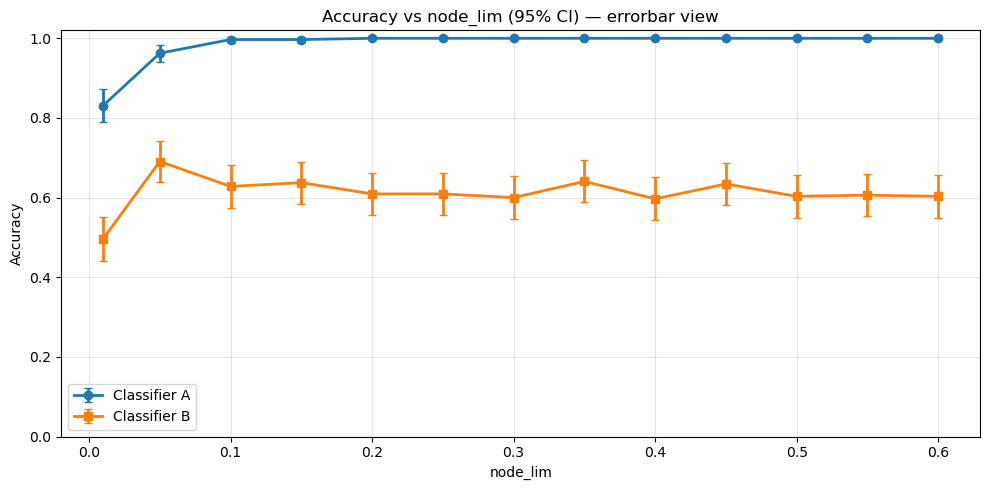

In [ ]:
# Lists to store results
node_lim = results_df_email["node_lim"].values

#email
accuracies_tda_email = []
ci_lower_tda_email = []
ci_upper_tda_email = []

accuracies_tda_email = results_df_email["accuracy"].values
ci_lower_tda_email = results_df_email["ci_lower"].values
ci_upper_tda_email = results_df_email["ci_upper"].values

for i in range(len(ci_upper_tda_email)):
    if ci_upper_tda_email[i] > 1:
        ci_upper_tda_email[i] = 1
#conf
accuracies_tda_conf = []
ci_lower_tda_conf = []
ci_upper_tda_conf = []

accuracies_tda_conf = results_df_conf["accuracy"].values
ci_lower_tda_conf = results_df_conf["ci_lower"].values
ci_upper_tda_conf = results_df_conf["ci_upper"].values


for i in range(len(ci_upper_tda_conf)):
    if ci_upper_tda_conf[i] > 1:
        ci_upper_tda_conf[i] = 1
#school
accuracies_tda_school = []
ci_lower_tda_school = []
ci_upper_tda_school = []

accuracies_tda_school = results_df_school["accuracy"].values
ci_lower_tda_school = results_df_school["ci_lower"].values
ci_upper_tda_school = results_df_school["ci_upper"].values


for i in range(len(ci_upper_tda_school)):
    if ci_upper_tda_school[i] > 1:
        ci_upper_tda_school[i] = 1

##-----------------------------------------------------------------
# Create the plot
plt.figure(figsize=(8, 6))

#email
plt.plot(node_lim, accuracies_tda_email, marker='o',label="email")
plt.fill_between(node_lim, ci_lower_tda_email, ci_upper_tda_email, alpha=0.2)
#conf
plt.plot(node_lim, accuracies_tda_conf, marker='o',label="conference")
plt.fill_between(node_lim, ci_lower_tda_conf, ci_upper_tda_conf, alpha=0.2)
#school
plt.plot(node_lim, accuracies_tda_school, marker='o',label="school")
plt.fill_between(node_lim, ci_lower_tda_school, ci_upper_tda_school, alpha=0.2)

# Set x-axis to show only integer values
plt.xticks(node_lim)


plt.xlabel('Observed Ratio',fontsize=15)
plt.ylabel('Accuracy',fontsize=15)
# plt.legend(loc='lower right',fontsize=15)

# plt.ylim(0.90,1.01)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='lower right',fontsize=15)


plt.grid(True)
# plt.legend(loc="lower right")

plt.tight_layout()
# plt.show()
# plt.savefig(f'./res/{network_name}_accuracy_plot_given_observed_node.pdf', format='pdf', dpi=1200, bbox_inches='tight')

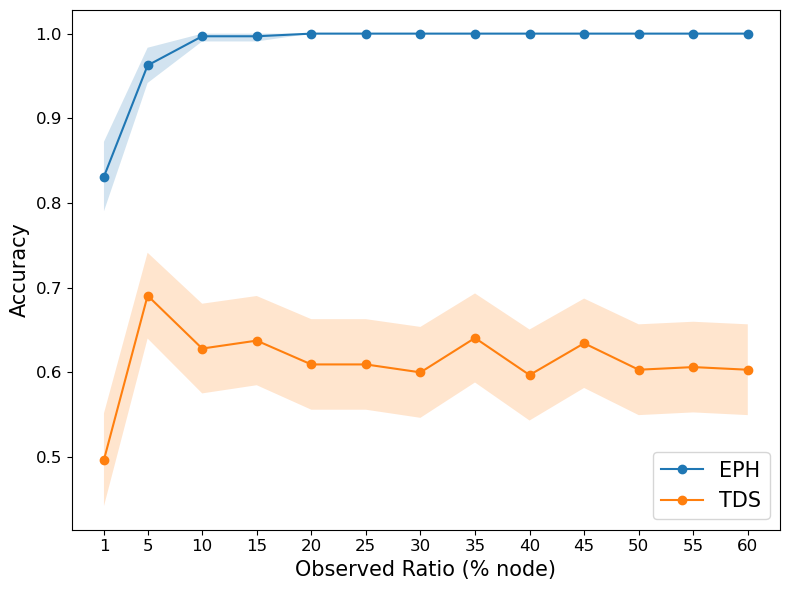

In [81]:
import numpy as np
import matplotlib.pyplot as plt

# --- prep ---
df = results_df_email.sort_values("node_lim").copy()

# convert to percentage
node_lim_pct = (df["node_lim"].values * 100).astype(int)

# classifier A
accuracies_cls1 = df["accuracy"].values.copy()
ci_lower_cls1   = df["ci_lower"].values.copy()
ci_upper_cls1   = df["ci_upper"].values.copy()

for i in range(len(ci_upper_cls1)):
    if ci_upper_cls1[i] > 1:
        ci_upper_cls1[i] = 1

# classifier B
accuracies_cls2 = df["accuracy_tds"].values.copy()
ci_lower_cls2   = df["ci_lower_tds"].values.copy()
ci_upper_cls2   = df["ci_upper_tds"].values.copy()

for i in range(len(ci_upper_cls2)):
    if ci_upper_cls2[i] > 1:
        ci_upper_cls2[i] = 1

# --- plot ---
plt.figure(figsize=(8, 6))

plt.plot(node_lim_pct, accuracies_cls1, marker='o', label="EPH")
plt.fill_between(node_lim_pct, ci_lower_cls1, ci_upper_cls1, alpha=0.2)

plt.plot(node_lim_pct, accuracies_cls2, marker='o', label="TDS")
plt.fill_between(node_lim_pct, ci_lower_cls2, ci_upper_cls2, alpha=0.2)

# show integer percentage ticks (e.g. 45 instead of 0.45)
plt.xticks(node_lim_pct)

plt.xlabel('Observed Ratio (% node)', fontsize=15)
plt.ylabel('Accuracy', fontsize=15)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='lower right', fontsize=15)

# plt.grid(True)
plt.tight_layout()

# save (same style as yours)
plt.savefig('./res/email_accuracy_tds_EPH_vs_observed_ratio.pdf',
            format='pdf', dpi=1200, bbox_inches='tight')

plt.show()

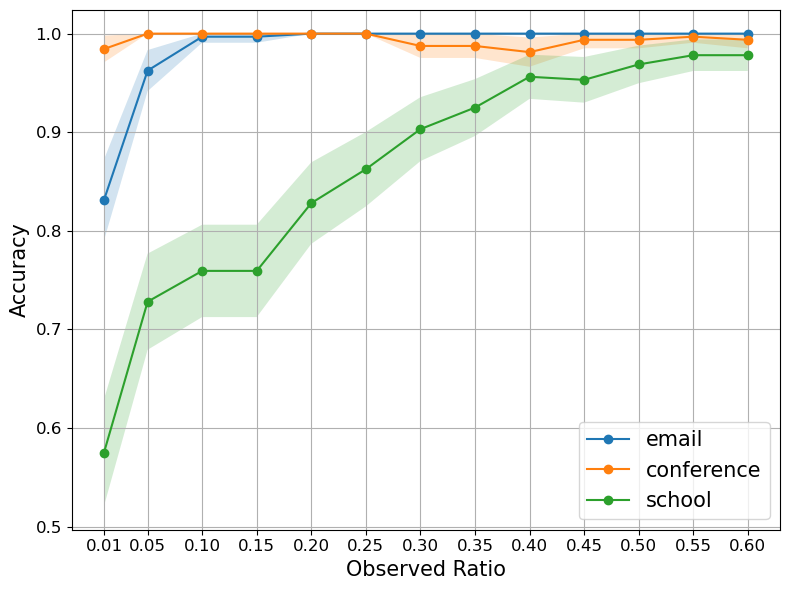

In [18]:
# Lists to store results
node_lim = results_df_email["node_lim"].values

#email
accuracies_tda_email = []
ci_lower_tda_email = []
ci_upper_tda_email = []

accuracies_tda_email = results_df_email["accuracy"].values
ci_lower_tda_email = results_df_email["ci_lower"].values
ci_upper_tda_email = results_df_email["ci_upper"].values

for i in range(len(ci_upper_tda_email)):
    if ci_upper_tda_email[i] > 1:
        ci_upper_tda_email[i] = 1
#conf
accuracies_tda_conf = []
ci_lower_tda_conf = []
ci_upper_tda_conf = []

accuracies_tda_conf = results_df_conf["accuracy"].values
ci_lower_tda_conf = results_df_conf["ci_lower"].values
ci_upper_tda_conf = results_df_conf["ci_upper"].values


for i in range(len(ci_upper_tda_conf)):
    if ci_upper_tda_conf[i] > 1:
        ci_upper_tda_conf[i] = 1
#school
accuracies_tda_school = []
ci_lower_tda_school = []
ci_upper_tda_school = []

accuracies_tda_school = results_df_school["accuracy"].values
ci_lower_tda_school = results_df_school["ci_lower"].values
ci_upper_tda_school = results_df_school["ci_upper"].values


for i in range(len(ci_upper_tda_school)):
    if ci_upper_tda_school[i] > 1:
        ci_upper_tda_school[i] = 1

##-----------------------------------------------------------------
# Create the plot
plt.figure(figsize=(8, 6))

#email
plt.plot(node_lim, accuracies_tda_email, marker='o',label="email")
plt.fill_between(node_lim, ci_lower_tda_email, ci_upper_tda_email, alpha=0.2)
#conf
plt.plot(node_lim, accuracies_tda_conf, marker='o',label="conference")
plt.fill_between(node_lim, ci_lower_tda_conf, ci_upper_tda_conf, alpha=0.2)
#school
plt.plot(node_lim, accuracies_tda_school, marker='o',label="school")
plt.fill_between(node_lim, ci_lower_tda_school, ci_upper_tda_school, alpha=0.2)

# Set x-axis to show only integer values
plt.xticks(node_lim)


plt.xlabel('Observed Ratio',fontsize=15)
plt.ylabel('Accuracy',fontsize=15)
# plt.legend(loc='lower right',fontsize=15)

# plt.ylim(0.90,1.01)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
plt.legend(loc='lower right',fontsize=15)


plt.grid(True)
# plt.legend(loc="lower right")

plt.tight_layout()
# plt.show()
# plt.savefig(f'./res/{network_name}_accuracy_plot_given_observed_node.pdf', format='pdf', dpi=1200, bbox_inches='tight')

In [138]:
(9565/(403*402)),(37873/(591*590)),(16706/(1005*1004))

(0.05904102317198128, 0.10861510223981187, 0.01655665893639373)

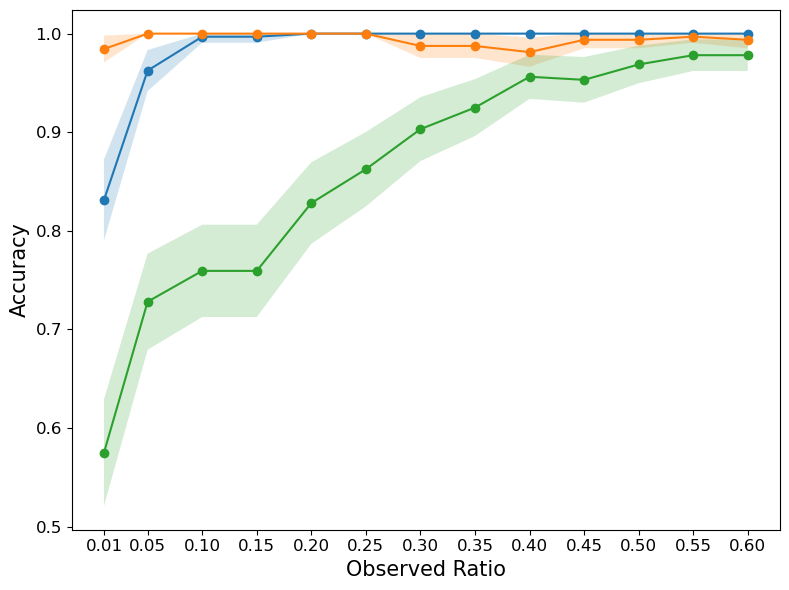

In [140]:
# Lists to store results
node_lim = results_df_email["node_lim"].values

#email
accuracies_tda_email = []
ci_lower_tda_email = []
ci_upper_tda_email = []

accuracies_tda_email = results_df_email["accuracy"].values
ci_lower_tda_email = results_df_email["ci_lower"].values
ci_upper_tda_email = results_df_email["ci_upper"].values
#conf
accuracies_tda_conf = []
ci_lower_tda_conf = []
ci_upper_tda_conf = []

accuracies_tda_conf = results_df_conf["accuracy"].values
ci_lower_tda_conf = results_df_conf["ci_lower"].values
ci_upper_tda_conf = results_df_conf["ci_upper"].values
#school
accuracies_tda_school = []
ci_lower_tda_school = []
ci_upper_tda_school = []

accuracies_tda_school = results_df_school["accuracy"].values
ci_lower_tda_school = results_df_school["ci_lower"].values
ci_upper_tda_school = results_df_school["ci_upper"].values

##-----------------------------------------------------------------
# Create the plot
plt.figure(figsize=(8, 6))

#email
plt.plot(node_lim, accuracies_tda_email, marker='o',label="email")
plt.fill_between(node_lim, ci_lower_tda_email, ci_upper_tda_email, alpha=0.2)
#conf
plt.plot(node_lim, accuracies_tda_conf, marker='o',label="conference")
plt.fill_between(node_lim, ci_lower_tda_conf, ci_upper_tda_conf, alpha=0.2)
#school
plt.plot(node_lim, accuracies_tda_school, marker='o',label="school")
plt.fill_between(node_lim, ci_lower_tda_school, ci_upper_tda_school, alpha=0.2)

# Set x-axis to show only integer values
plt.xticks(node_lim)


plt.xlabel('Observed Ratio',fontsize=15)
plt.ylabel('Accuracy',fontsize=15)
# plt.legend(loc='lower right',fontsize=15)

# plt.ylim(0.90,1.01)

plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
# plt.legend(loc='lower right',fontsize=15)


# plt.grid(True)
# plt.legend(loc="lower right")

plt.tight_layout()
# plt.show()
plt.savefig(f'../plot-april-final-version/fig4-panelA.pdf', format='pdf', dpi=1200, bbox_inches='tight')

In [20]:
complex_all

,0,1,2,3,4,5,6,7,8,9,...,588,589,590,seed,complex_param,simple_infection_ratio,EPH,corr,seed_obs,obs_ratio
0,2,2,2,2.0,2.0,3,2,3.0,2.0,3.0,...,2.0,2.0,3.0,0,5,0.037234,1.091588,-0.398753,30344742,0.60
1,2,3,3,2.0,3.0,3,3,2.0,3.0,2.0,...,2.0,3.0,3.0,1,5,0.031746,1.103685,-0.336857,30344742,0.60
2,2,3,3,3.0,2.0,3,2,2.0,2.0,3.0,...,2.0,2.0,3.0,2,5,0.031802,1.074990,-0.373209,30344742,0.60
3,3,2,2,2.0,3.0,2,2,2.0,2.0,3.0,...,2.0,3.0,3.0,3,5,0.033569,1.077880,-0.449585,30344742,0.60
4,2,2,2,3.0,3.0,2,2,3.0,2.0,1.0,...,3.0,2.0,3.0,4,5,0.029930,1.043608,-0.319169,30344742,0.60
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,2,2,2,2.0,1.0,1,1,1.0,1.0,2.0,...,2.0,2.0,2.0,195,2,0.003431,0.000000,-1.000000,65788080,0.01
196,1,2,1,1.0,2.0,1,1,2.0,1.0,1.0,...,1.0,2.0,2.0,196,2,0.001712,1.000000,1.000000,65788080,0.01
197,1,1,1,1.0,1.0,1,1,1.0,2.0,2.0,...,1.0,2.0,2.0,197,2,0.005155,0.000000,NaN,65788080,0.01
198,2,1,1,1.0,2.0,1,1,2.0,2.0,2.0,...,2.0,2.0,1.0,198,2,0.013865,1.000000,1.000000,65788080,0.01


In [160]:
simple_betas = [0.02,0.03,0.04,0.05]
complex_thetas = [2,3,4]
complex_probs = [-1,0.02]
#0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,
observable_ratio = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1]
observable_ratio = [0.01,0.02,0.03,0.04,0.05,0.06,0.07,0.08,0.09,0.1]
# observable_ratio = [0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9]

network_list = ['email_eu_modified']
network_list = ['school']

In [192]:
results_dir = '../result_85stop_10%init_nodes_limited-v4/unweighted/'
network_name = "email_eu_modified"
complex_all = pd.DataFrame()

for theta in tqdm(complex_thetas):
    for prob_complex in complex_probs:
        for obs_ratio in observable_ratio:
            
            #raw csv path
            csv_path = os.path.join(results_dir, f'unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}.csv')
            #path with EPH
            output_csv = csv_path.replace('.csv', f'limited-node_{obs_ratio}_EPH-v3.csv')
            
            df = pd.read_csv(output_csv)
            df["obs_ratio"] = obs_ratio
            
            complex_all = pd.concat([df,complex_all])           

100%|█████████████████████████████████████████████| 3/3 [00:01<00:00,  2.90it/s]


In [193]:
# complex_all = complex_all[~complex_all["EPH"].isna()]
complex_all["EPH"] = complex_all["EPH"].fillna(0)
complex_all.to_csv("./limited_info/complex_all.csv")

In [195]:
# Process simple contagion CSVs
simple_all = pd.DataFrame()

for obs_ratio in observable_ratio:
    for beta in simple_betas:
        #raw csv path
        csv_path = os.path.join(results_dir, f'unweighted_simple_{network_name}_beta_{beta}.csv')
        #path with EPH
        output_csv = csv_path.replace('.csv', f'limited-node_{obs_ratio}_EPH-v2.csv')
        
        df = pd.read_csv(output_csv)
        df["obs_ratio"] = obs_ratio
            
        simple_all = pd.concat([df,simple_all])    


In [196]:
# simple_all = simple_all[~simple_all["EPH"].isna()]
simple_all["EPH"] = simple_all["EPH"].fillna(0)
simple_all.to_csv("./limited_info/simple_all.csv")

### Visualization

In [199]:
results = []
for node_lim in tqdm(observable_ratio):
    simple_samples = simple_all.sample(frac=1,random_state=42)
    complex_samples = complex_all.sample(frac=1,random_state=42)
    
    if len(simple_samples) > len(complex_samples):
        simple_samples = simple_samples.sample(n=len(complex_samples),random_state=42)
    else:
        complex_samples = complex_samples.sample(n=len(simple_samples),random_state=42)
        
    # Extract features and labels
    complex_EPH = complex_samples[complex_samples["obs_ratio"] == node_lim]['EPH'].values
    simple_EPH = simple_samples[simple_samples["obs_ratio"] == node_lim]['EPH'].values

    X = np.concatenate([complex_EPH, simple_EPH]).reshape(-1, 1)  # Features
    y = np.concatenate([np.ones(len(complex_EPH)), np.zeros(len(simple_EPH))])  # Labels (1=complex, 0=simple)

       # Shuffle data
    indices = np.arange(X.shape[0])
    np.random.seed(42) 
    np.random.shuffle(indices)
    X = X[indices]
    y = y[indices]

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=420)

    # Train Decision Tree Classifier
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X_train, y_train)

    # Evaluate the classifier
    y_pred = clf.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    ci_lower, ci_upper = compute_confidence_interval(accuracy, len(y_test))

    # Store the results
    results.append({
        'node_lim': node_lim,
        'accuracy': accuracy,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper
    })

# Convert results to a DataFrame
results_df = pd.DataFrame(results)


100%|███████████████████████████████████████████| 10/10 [00:00<00:00, 16.88it/s]


In [200]:
results_df.to_csv(f'./res/{network_name}_results.csv')

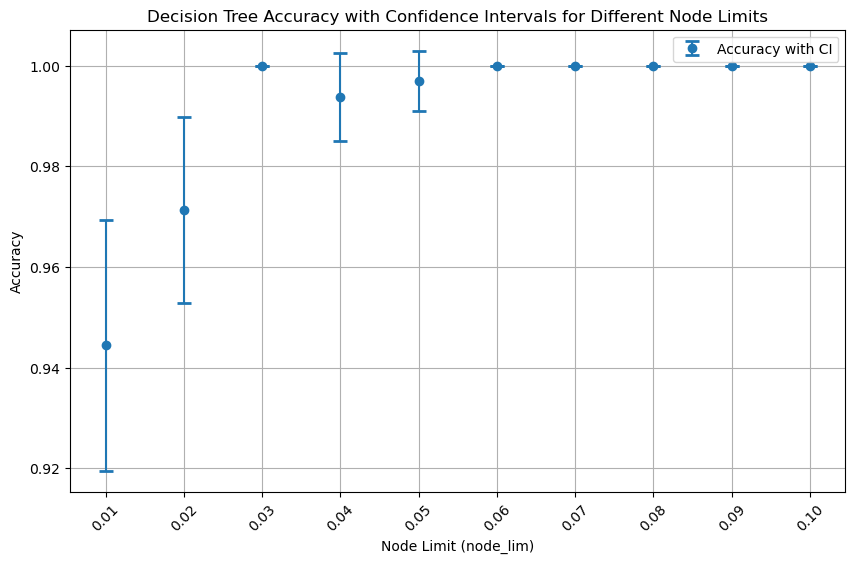

In [202]:
# Plot results
plt.figure(figsize=(10, 6))
plt.errorbar(
    results_df['node_lim'],
    results_df['accuracy'],
    yerr=[results_df['accuracy'] - results_df['ci_lower'], results_df['ci_upper'] - results_df['accuracy']],
    fmt='o',
    capsize=5,
    capthick=2,
    label='Accuracy with CI'
)
plt.xticks(results_df['node_lim'], rotation=45)
plt.xlabel('Node Limit (node_lim)')
plt.ylabel('Accuracy')
plt.title('Decision Tree Accuracy with Confidence Intervals for Different Node Limits')
plt.grid(True)
plt.legend()
plt.show()


In [204]:
network_name = "email_eu_modified"
results_df_email = pd.read_csv(f'./res/{network_name}_results.csv')
network_name = "conf"
results_df_conf = pd.read_csv(f'./res/{network_name}_results.csv')
network_name = "school"
results_df_school = pd.read_csv(f'./res/{network_name}_results.csv')

In [205]:
results_df_email["ci_upper"] = results_df_email["ci_upper"].apply(lambda x: min(1,x))
results_df_conf["ci_upper"] = results_df_conf["ci_upper"].apply(lambda x: min(1,x))
results_df_school["ci_upper"] = results_df_school["ci_upper"].apply(lambda x: min(1,x))

In [206]:
a = [1,2,4]
a[:2]

[1, 2]

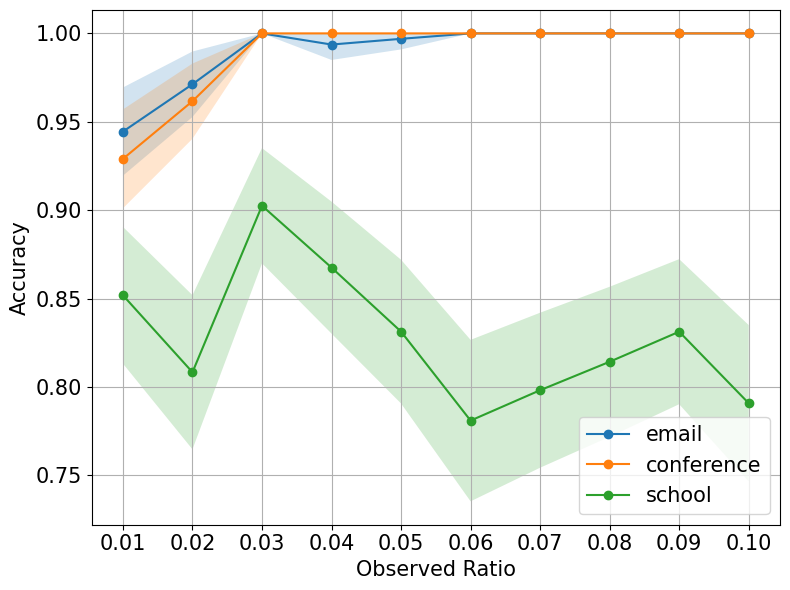

In [209]:
# Lists to store results
node_lim = results_df_email["node_lim"].values

#email
accuracies_tda_email = []
ci_lower_tda_email = []
ci_upper_tda_email = []

accuracies_tda_email = results_df_email["accuracy"].values
ci_lower_tda_email = results_df_email["ci_lower"].values
ci_upper_tda_email = results_df_email["ci_upper"].values
#conf
accuracies_tda_conf = []
ci_lower_tda_conf = []
ci_upper_tda_conf = []

accuracies_tda_conf = results_df_conf["accuracy"].values
ci_lower_tda_conf = results_df_conf["ci_lower"].values
ci_upper_tda_conf = results_df_conf["ci_upper"].values
#school
accuracies_tda_school = []
ci_lower_tda_school = []
ci_upper_tda_school = []

accuracies_tda_school = results_df_school["accuracy"].values
ci_lower_tda_school = results_df_school["ci_lower"].values
ci_upper_tda_school = results_df_school["ci_upper"].values

##-----------------------------------------------------------------
# Create the plot
plt.figure(figsize=(8, 6))

#email
plt.plot(node_lim, accuracies_tda_email, marker='o',label="email")
plt.fill_between(node_lim, ci_lower_tda_email, ci_upper_tda_email, alpha=0.2)
#conf
plt.plot(node_lim, accuracies_tda_conf, marker='o',label="conference")
plt.fill_between(node_lim, ci_lower_tda_conf, ci_upper_tda_conf, alpha=0.2)
#school
plt.plot(node_lim, accuracies_tda_school, marker='o',label="school")
plt.fill_between(node_lim, ci_lower_tda_school, ci_upper_tda_school, alpha=0.2)

# Set x-axis to show only integer values
plt.xticks(node_lim)


plt.xlabel('Observed Ratio',fontsize=15)
plt.ylabel('Accuracy',fontsize=15)
# plt.legend(loc='lower right',fontsize=15)

# plt.ylim(0.90,1.01)

plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.legend(loc='lower right',fontsize=15)


plt.grid(True)
# plt.legend(loc="lower right")

plt.tight_layout()
# plt.show()
plt.savefig(f'./res/{network_name}_accuracy_plot_given_observed_node.pdf', format='pdf', dpi=1200, bbox_inches='tight')

## Marge all data sets 

In [13]:
#read and preprocessing data
network_list = [
    'conf','email_eu_modified','school'
]

simple_betas = [0.02,0.03,0.04,0.05]
complex_thetas = [2,3,4]
complex_probs = [-1,0.02,0.03,0.04]

In [15]:
complex_all = pd.DataFrame()

for theta in tqdm(complex_thetas):
    for prob_complex in complex_probs:
        for network_name in network_list:
            output_csv = f"../result_85stop_10%init_nodes-v3/unweighted/unweighted_complex_{network_name}_theta_{theta}_prob_{prob_complex}_EPH-v2.csv"
            
            df = pd.read_csv(output_csv)
            df = df[["EPH","corr"]]
            complex_all = pd.concat([df,complex_all])   

100%|█████████████████████████████████████████████| 3/3 [00:00<00:00, 10.72it/s]


In [17]:
# Process simple contagion CSVs
simple_all = pd.DataFrame()

for network_name in network_list:
    for beta in simple_betas:
        output_csv = f'../result_85stop_10%init_nodes-v3/unweighted/unweighted_simple_{network_name}_beta_{beta}_EPH-v2.csv'
        df = pd.read_csv(output_csv)
        df = df[["EPH","corr"]]   
        simple_all = pd.concat([df,simple_all])    


In [19]:
complex_all = complex_all.sample(len(simple_all),random_state=1024)

In [21]:
simple_all["complex"] = 0 
complex_all["complex"] = 1

In [23]:
df_all = pd.concat([simple_all,complex_all]).sample(frac=1,random_state=42987)

In [25]:
df_all = df_all.dropna()

In [27]:
# Shuffle data
X_tda = df_all[["EPH"]]
X_corr = df_all[["corr"]]

y = df_all["complex"]

# Split into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(X_tda, y, test_size=0.2, random_state=420)
X_train2, X_test2, y_train2, y_test2 = train_test_split(X_corr, y, test_size=0.2, random_state=420)

# Train Decision Tree Classifier
clf1 = DecisionTreeClassifier(random_state=42)
clf2 = DecisionTreeClassifier(random_state=42)

clf1.fit(X_train1, y_train1)
clf2.fit(X_train2, y_train2)

# Evaluate the classifier
y_pred1 = clf1.predict(X_test1)
accuracy1 = accuracy_score(y_test1, y_pred1)
ci_lower1, ci_upper1 = compute_confidence_interval(accuracy1, len(y_test1))

y_pred2 = clf2.predict(X_test2)
accuracy2 = accuracy_score(y_test2, y_pred2)
ci_lower2, ci_upper2 = compute_confidence_interval(accuracy2, len(y_test2))


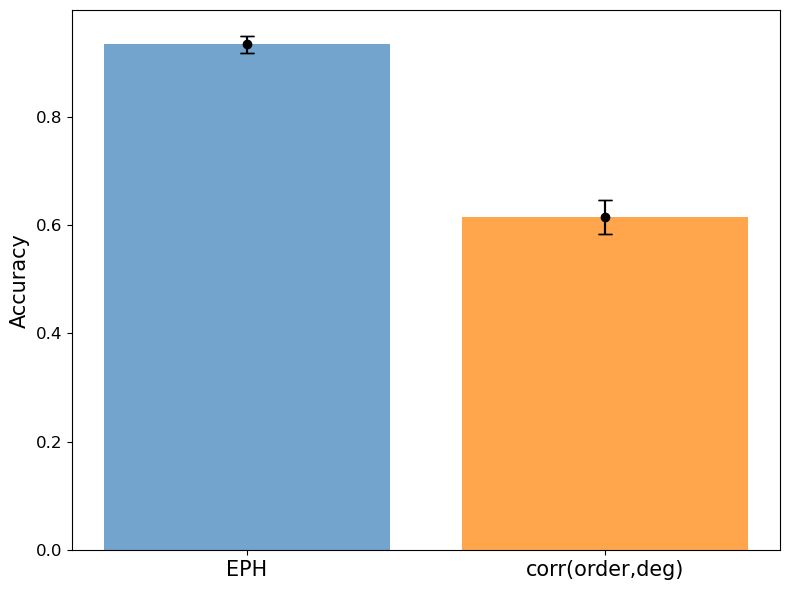

In [29]:
import matplotlib.pyplot as plt
import numpy as np

# Data
accuracies = [accuracy1, accuracy2]
ci_lowers = [ci_lower1, ci_lower2]
ci_uppers = [ci_upper1, ci_upper2]
labels = ['EPH', 'corr(order,deg)']

# Positions for the bars
x_pos = np.arange(len(labels))

# Plotting

fig, ax = plt.subplots(figsize=(8, 6))

# Plot the accuracies
ax.bar(x_pos, accuracies, yerr=[accuracies[i] - ci_lowers[i] for i in range(len(accuracies))], 
       capsize=5, color=['#377eb8', '#ff7f00'], alpha=0.7, label='Accuracy')

# Plot the confidence intervals
for i, (lower, upper) in enumerate(zip(ci_lowers, ci_uppers)):
    ax.errorbar(x_pos[i], accuracies[i], yerr=[[accuracies[i] - lower], [upper - accuracies[i]]], 
                fmt='o', color='black', capsize=5)

# Add labels, title, and legend
ax.set_xticks(x_pos)
ax.set_xticklabels(labels,fontsize=15)
ax.set_ylabel('Accuracy',fontsize=15)
plt.yticks(fontsize=12)
# ax.set_title('Accuracy Comparison with Confidence Intervals')
# ax.legend()

# Show the plot
plt.tight_layout()
# plt.show()
plt.savefig(f'./res/mixed_dataset_results.pdf', format='pdf', dpi=1200, bbox_inches='tight')

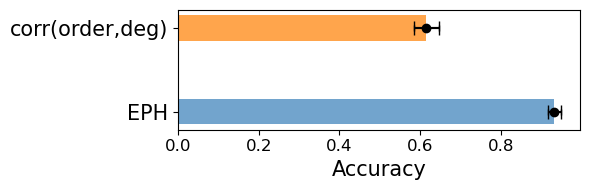

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Data
accuracies = [accuracy1, accuracy2]
ci_lowers = [ci_lower1, ci_lower2]
ci_uppers = [ci_upper1, ci_upper2]
labels = ['EPH', 'corr(order,deg)']

# Positions for the bars
y_pos = np.arange(len(labels))

# Plotting
fig, ax = plt.subplots(figsize=(6, 2))  # Adjusted height for horizontal layout

# Plot the accuracies (horizontal bars)
ax.barh(y_pos, accuracies, 
        xerr=[accuracies[i] - ci_lowers[i] for i in range(len(accuracies))], 
        capsize=2, color=['#377eb8', '#ff7f00'], alpha=0.7, height=0.3, label='Accuracy')

# Plot the confidence intervals
for i, (lower, upper) in enumerate(zip(ci_lowers, ci_uppers)):
    ax.errorbar(accuracies[i], y_pos[i], 
                xerr=[[accuracies[i] - lower], [upper - accuracies[i]]], 
                fmt='o', color='black', capsize=5)

# Add labels, title, and legend
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=15)
ax.set_xlabel('Accuracy', fontsize=15)
plt.xticks(fontsize=12)
# ax.set_title('Accuracy Comparison with Confidence Intervals')
# ax.legend()

# Show the plot
plt.tight_layout()
# plt.show()
plt.savefig('./res/mixed_dataset_results.pdf', format='pdf', dpi=1200, bbox_inches='tight')


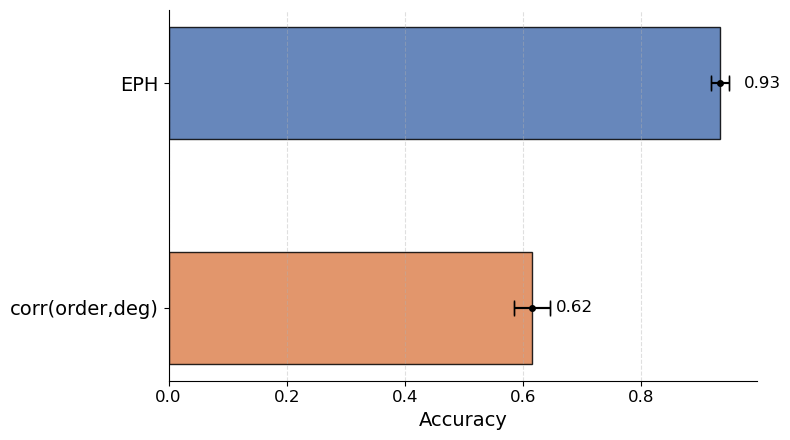

In [49]:
import matplotlib.pyplot as plt
import numpy as np

# Data
accuracies = [accuracy1, accuracy2]
ci_lowers = [ci_lower1, ci_lower2]
ci_uppers = [ci_upper1, ci_upper2]
labels = ['EPH', 'corr(order,deg)']

# Bar positions
y_pos = np.arange(len(labels))

# Set up plot
fig, ax = plt.subplots(figsize=(8, 4.5))

# Bar colors and style
colors = ['#4c72b0', '#dd8452']

# Plot horizontal bars
bars = ax.barh(y_pos, accuracies, 
               xerr=[accuracies[i] - ci_lowers[i] for i in range(len(accuracies))],
               capsize=6, height=0.5, 
               color=colors, edgecolor='black', alpha=0.85)

# Add confidence interval caps
for i, (lower, upper) in enumerate(zip(ci_lowers, ci_uppers)):
    ax.errorbar(accuracies[i], y_pos[i], 
                xerr=[[accuracies[i] - lower], [upper - accuracies[i]]], 
                fmt='o', color='black', capsize=5, markersize=4)

# Add accuracy labels on bars
for i, bar in enumerate(bars):
    width = bar.get_width()
    ax.text(width + 0.04, bar.get_y() + bar.get_height()/2,
            f"{accuracies[i]:.2f}", va='center', fontsize=12, color='black')

# Axis styling
ax.set_yticks(y_pos)
ax.set_yticklabels(labels, fontsize=14)
ax.set_xlabel('Accuracy', fontsize=14)
plt.xticks(fontsize=12)
ax.invert_yaxis()  # Optional: Highest value on top

# Gridlines for x-axis
ax.xaxis.grid(True, linestyle='--', alpha=0.4)

# Remove top and right borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Tight layout and save
plt.tight_layout()
plt.savefig('../plot-april-final-version/fig4_panelA_inset.pdf', format='pdf', dpi=1200, bbox_inches='tight')
